In [1]:
from hapi import *

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
# from hapi import *

from scipy.signal import correlate

%matplotlib widget

In [3]:
os.getcwd()

'/Users/zaniaccollins/Desktop/SGL/Python'

In [3]:
db_begin('HAPI_DB')

Using HAPI_DB

1_1
                     Lines parsed: 111591
CH3OH
                     Lines parsed: 15234
CH3F
                     Lines parsed: 9069
CH4
                     Lines parsed: 200655
H2O_C_18O)
                     Lines parsed: 101
CO2_2
                     Lines parsed: 69367
2_2
                     Lines parsed: 69367
co2_isotopologues
                     Lines parsed: 2897
CO2_C_16O)2
                     Lines parsed: 12758
H20
                     Lines parsed: 58143
SO3_iso1_1.670-16.670um
                     Lines parsed: 3541
CO2_C_13
                     Lines parsed: 2897
SO2
                     Lines parsed: 350816
SO2_iso1_1.670-16.670um
                     Lines parsed: 350816
SO
                     Lines parsed: 40527
H2S_iso1_1.670-16.670um
                     Lines parsed: 67541
OCS
                     Lines parsed: 459210
C4H2
                     Lines parsed: 162450
C2H6
                     Lines parsed: 52648
CO2_C_12
                     

In [6]:
def download(molecule_list, isotope_list):
    for molecule in molecule_list:
        molecule_name = ISO[(molecule, 1)][-1]  # Get the molecule name from the ISO dictionary
        for isotope in isotope_list:
            print(f"Fetching data for molecule {molecule}, isotopologue {isotope}...")
            fetch(f'{molecule_name}_{isotope}', molecule, isotope, 0, 1e4)  # Fetching a wide range to ensure we get all lines

def generate_isotopologue_dictionary(table_name, molecule_number, wavelength_min, wavelength_max,
                           dwn, desired_isos, T=296.0, p=1.0):

    wn_min = 1e4 / wavelength_max
    wn_max = 1e4 / wavelength_min

    # For testing, we can use a fixed column density and path length to compute the optical depth and transmission.
    column_density = 1e12
    path_length = 1e5  

    isotopologue_dictionary = {}

    for i in desired_isos:
        isotopologue_number = i

        iso_key = (molecule_number, isotopologue_number)
        iso_formula = ISO[iso_key][1]
        molecule_name = ISO[iso_key][-1]
        carbon_mass = iso_formula.split('C')[0].split('(')[1]  # Extract carbon mass (e.g., '12' or '13')
        temp_table = f"{molecule_name}_C_{carbon_mass}"
        print(f"Processing isotopologue {isotopologue_number}: {iso_formula} using table {temp_table}")

        if temp_table not in tableList():
            print(f"Table {temp_table} not found locally. Fetching from HITRAN...")
            fetch(temp_table, molecule_number, isotopologue_number, wn_min, wn_max)
        else:
            # Check if there are lines in the specific wavenumber range
            select(f'{temp_table}')
            num_lines = LOCAL_TABLE_CACHE[temp_table]['header']['number_of_rows']
            # dropTable(f'{temp_table}')
            if num_lines == 0:
                print(f"No lines in range for {temp_table}. Fetching from HITRAN...")
                fetch(temp_table, molecule_number, isotopologue_number, wn_min, wn_max)

        # Now compute absorption coefficient using the table (which exists and has data in range)
        wn_grid, coef = absorptionCoefficient_Voigt(
            SourceTables=temp_table,
            WavenumberRange=(wn_min, wn_max),
            WavenumberStep=dwn,
            Environment={'T': T, 'p': p} 
        )

        # Calculate optical depth and transmission
        tau = coef * column_density * path_length

        # Assuming I0 = 1 for simplicity, coming from beer-lambert law: I = I0 * exp(-tau)
        transmission = np.exp(-tau)

        wavelength_grid = 1e4 / wn_grid

        resolution = np.median(wn_grid) / dwn
        print(f"Isotopologue {isotopologue_number}: Wavelength range {wavelength_grid[0]:.2f} µm to {wavelength_grid[-1]:.2f} µm, Resolution {resolution:.2f} cm^-1")

        isotopologue_dictionary[isotopologue_number] = {
            'Isotopologue': iso_formula,
            'wavelength_grid': wavelength_grid,
            'wn_grid': wn_grid,
            'raw_coef': coef,
            'transmission': transmission,
            'tau': tau,
            'spec_res': resolution
        }
    return isotopologue_dictionary

def inject_poisson_noise(data, SNR):

    signal = np.average(data)  # Representative signal level for scaling noise
    print(f"Average signal level: {signal:.4e}")
    scale = signal / SNR if signal > 0 else 1.0 
    print(f"scale factor: {scale:.4e} for SNR={SNR}")

    poisson_noise = np.random.poisson(lam=data)
    poisson_noise = poisson_noise - data  # Center the noise around zero
    
    noisy_data = data + poisson_noise * scale / np.sqrt(signal)  # Scale noise by SNR and signal level
    noisy_data = np.clip(noisy_data, 0, None)  # Ensure non-negative values

    errorbars = np.sqrt(data) * scale / np.sqrt(signal)  # Poisson noise error bars

    return noisy_data, errorbars


def inject_gaussian_noise(data, SNR, seed = 8):

    signal = np.max(data) 
    sigma = signal / SNR

    nchan = len(data)
    rng = np.random.default_rng(seed)
    random_pertubations = sigma*rng.standard_normal(nchan)


    synthetic_atmosphere = data + random_pertubations 
    synthetic_atmosphere = np.clip(synthetic_atmosphere, 0, None) 
    
    errorbars = np.full_like(data, sigma) 
    return synthetic_atmosphere, errorbars

def create_abundance_weighted_sum(iso_data, dwn, snr_val, abundances_dict):
    summed_transmission = None
    wl_grid = None
    
    for iso_num, frac in abundances_dict.items():
        if iso_num not in iso_data[dwn]:
            continue
            
        data = iso_data[dwn][iso_num][snr_val]

        
        if summed_transmission is None:
            wl_grid = data['wavelength_grid']
            summed_transmission = data['transmission'] * frac
        else:
            summed_transmission += data['transmission'] * frac
    
    return wl_grid, summed_transmission

def load_co2_data():
    """Load previously saved isotopologue data."""
    data = {}
    
    folder = 'co2_isotopologue_data'
    if not os.path.exists(folder):
        print("No saved data found")
        return None
        
    for file in sorted(os.listdir(folder)):
        if file.endswith('.npz'):
            print(f"Loading file: {file}")
            path = os.path.join(folder, file)
            loaded = np.load(path, allow_pickle=True)
            
            # Reconstruct the nested structure
            dwn = os.path.splitext(file)[0].split('_')[-1]  # Extract dwn from filename
            dwn = float(dwn)  # Convert dwn to float
            print(f"Loading data for dwn={dwn} from {file}")
            iso_num = os.path.splitext(file)[0].split('_')[-3]  # Extract iso_num from filename
            iso_num = int(iso_num)  # Convert iso_num to int
            print(f"  Extracted iso_num={iso_num} from filename")
            
            if dwn not in data:
                data[dwn] = {}
            
            # Convert back to regular dict
            iso_dict = {key: loaded[key] for key in loaded.files 
                       if key not in ['dwn', 'iso_num']}
            
            data[dwn][iso_num] = iso_dict
            
            print(f"  Loaded: dwn={dwn}, iso={iso_num}")
    return data

# CH4

## Obtain CH4 data

In [ ]:
ch4_isotopologues = [1,2]

dwns = [10,8,6,5,1,0.5,0.25,0.1, 0.05, 0.025, 0.01] #Define step number (i.e. resolution) for the wavenumber grid
print(ch4_isotopologues)

ch4_isotopologue_dictionary = {} # initialize empty dictionary to store isotopologue data for each dwn

for dwn in dwns:
    ch4_isotopologue_dictionary[dwn] = generate_isotopologue_dictionary( # generate dictionary for each dwn
        table_name='ch4_isotopologues',
        molecule_number=6,
        wavelength_min=3.5,
        wavelength_max=3.8,
        dwn=dwn,
        desired_isos=ch4_isotopologues,
        T=296.0,
        p=1.0
    )

# Exporting data
os.makedirs('ch4_isotopologue_data', exist_ok=True)
for dwn in ch4_isotopologue_dictionary:
    for iso_num, iso_data in ch4_isotopologue_dictionary[dwn].items():
        filename = f'ch4_isotopologue_data/ch4_iso_{iso_num}_dwn_{dwn}.npz'
        np.savez(filename, **iso_data)

[1, 2]
Processing isotopologue 1: H2(16O) using table H2O_C_16O)
Table H2O_C_16O) not found locally. Fetching from HITRAN...

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O_C_16O)
  65536 bytes written to HAPI_DB/H2O_C_16O).data
  65536 bytes written to HAPI_DB/H2O_C_16O).data
  65536 bytes written to HAPI_DB/H2O_C_16O).data
Header written to HAPI_DB/H2O_C_16O).header
END DOWNLOAD
                     Lines parsed: 1164
PROCESSED


/Users/zaniaccollins/Desktop/SGL/Python/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline


{'air': 1.0}
0.399180 seconds elapsed for abscoef; nlines = 1164
Isotopologue 1: Wavelength range 3.80 µm to 3.51 µm, Resolution 274.16 cm^-1
Processing isotopologue 2: H2(18O) using table H2O_C_18O)
Table H2O_C_18O) not found locally. Fetching from HITRAN...

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O_C_18O)
  65536 bytes written to HAPI_DB/H2O_C_18O).data
Header written to HAPI_DB/H2O_C_18O).header
END DOWNLOAD
                     Lines parsed: 101
PROCESSED


/Users/zaniaccollins/Desktop/SGL/Python/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline


{'air': 1.0}
0.050983 seconds elapsed for abscoef; nlines = 101
Isotopologue 2: Wavelength range 3.80 µm to 3.51 µm, Resolution 274.16 cm^-1
Processing isotopologue 1: H2(16O) using table H2O_C_16O)
 MI          nu         S         A gair gsel        E_nair    dair              V             V_              Q             Q_  ierr        Ireff      g     g_
 11 2631.767421 2.974E-28 1.325E-05.06660.315 1631.38300.63-.008900          0 2 0          0 0 0  9  1  8        9  6  3      534223837260713049    57.0   57.0
 11 2633.224935 9.416E-29 3.527E-07.09200.391  742.07300.73-.006090          0 2 0          0 0 0  4  0  4        5  5  1      532230837260713049     9.0   11.0
 11 2633.370040 1.199E-30 3.855E-06.08420.352 2462.87530.75-.007070          0 0 1          0 1 0  7  7  1        7  3  4      532230837294713152    45.0   45.0
 11 2633.764052 1.033E-29 1.502E-04.07640.333 2595.81290.700.004640          0 2 0          0 1 0  9  7  3        8  2  6      434233837294713152    19.0   1

## Normalize to equal intensities

In [ ]:
representative_iso = 1   # Use isotope 1 as the reference for max value

scaled_data={}

for dwn in ch4_isotopologue_dictionary:
    ref_min = np.min(ch4_isotopologue_dictionary[dwn][representative_iso]['transmission']) #representative min value for scaling
    ref_depth = 1 - ref_min
    
    # print(f"dwn={dwn} → Isotope {representative_iso} min = {ref_max:.4f}")
    
    for iso_num, iso_data in ch4_isotopologue_dictionary[dwn].items():
        
        data = iso_data['transmission']
        current_min = np.min(data)
        current_depth = 1-current_min
        # print(f'current_depth = {current_depth:.4f}, ref_depth = {ref_depth:.4f}')
        
        if current_min > 0:
            if current_min == ref_min:
                scaled_data = data
            else:
                scaling_factor = ref_depth / current_depth
                scaled_data = 1.0 - (1.0 - data) * scaling_factor
                # print(f"  Iso {iso_num}: original min = {current_min:.4f} → scaled to {ref_min:.4f} with scaling factor {scaling_factor:.4f}")
        else:
            scaled_data = data
            # print(f"  Iso {iso_num}: original min = {current_min:.4f} → scaled to {ref_min:.4f}")   
        iso_data['transmission_scaled'] = scaled_data
        # print(f"  Iso {iso_num}: original min = {current_min:.4f} → scaled to {ref_min:.4f}")

for dwn in ch4_isotopologue_dictionary:
    for iso_num in list(ch4_isotopologue_dictionary[dwn].keys()):
        if 'transmission_scaled' in ch4_isotopologue_dictionary[dwn][iso_num]:
            trans = ch4_isotopologue_dictionary[dwn][iso_num]['transmission_scaled']
            ch4_isotopologue_dictionary[dwn][iso_num]['tau_normalized'] = -np.log(trans)
            print(f"✓ Added tau_normalized for dwn={dwn} cm⁻¹, iso={iso_num}")
print("\nAll tau_normalized now use equal line depths → abundances will work correctly!")

# CO2

## Generating Spectra

In [7]:
co2_isotopologues = [1,  # 12C16O2,]
                     2,  # 13C16O2,
]

In [8]:
if "CO2_C_12" not in tableList():
    print("CO2_C_12 not found locally. Downloading...")
    # download([2], [1])  # Download 12C16O2
else:
    print("CO2_C_12 found locally. Skipping download.")

CO2_C_12 found locally. Skipping download.


In [9]:
# dwns = [10,8,6,5,1,0.5,0.25,0.1, 0.05, 0.025, 0.01]
# print(co2_isotopologues)

# co2_isotopologue_dictionary = {}

# for dwn in dwns:
#     co2_isotopologue_dictionary[dwn] = generate_isotopologue_dictionary(
#         table_name='co2_isotopologues',
#         molecule_number=2,
#         wavelength_min=4.125,
#         wavelength_max=4.45,
#         dwn=dwn,
#         desired_isos=co2_isotopologues,
#         T=296.0,
#         p=1.0
#     )

# # Exporting data
# os.makedirs('co2_isotopologue_data', exist_ok=True)
# for dwn in co2_isotopologue_dictionary:
#     for iso_num, iso_data in co2_isotopologue_dictionary[dwn].items():
#         filename = f'co2_isotopologue_data/co2_iso_{iso_num}_dwn_{dwn}.npz'
#         np.savez(filename, **iso_data)

In [10]:
co2_isotopologue_dictionary = load_co2_data();

Loading file: co2_iso_10_dwn_0.01.npz
Loading data for dwn=0.01 from co2_iso_10_dwn_0.01.npz
  Extracted iso_num=10 from filename
  Loaded: dwn=0.01, iso=10
Loading file: co2_iso_10_dwn_0.025.npz
Loading data for dwn=0.025 from co2_iso_10_dwn_0.025.npz
  Extracted iso_num=10 from filename
  Loaded: dwn=0.025, iso=10
Loading file: co2_iso_10_dwn_0.05.npz
Loading data for dwn=0.05 from co2_iso_10_dwn_0.05.npz
  Extracted iso_num=10 from filename
  Loaded: dwn=0.05, iso=10
Loading file: co2_iso_10_dwn_0.1.npz
Loading data for dwn=0.1 from co2_iso_10_dwn_0.1.npz
  Extracted iso_num=10 from filename
  Loaded: dwn=0.1, iso=10
Loading file: co2_iso_10_dwn_0.25.npz
Loading data for dwn=0.25 from co2_iso_10_dwn_0.25.npz
  Extracted iso_num=10 from filename
  Loaded: dwn=0.25, iso=10
Loading file: co2_iso_10_dwn_0.5.npz
Loading data for dwn=0.5 from co2_iso_10_dwn_0.5.npz
  Extracted iso_num=10 from filename
  Loaded: dwn=0.5, iso=10
Loading file: co2_iso_10_dwn_1.npz
Loading data for dwn=1.0 fr

## Normalizing (to equal intensities)

In [11]:
representative_iso = 1   # Use isotope 1 as the reference for max value

scaled_data={}

for dwn in co2_isotopologue_dictionary:
    ref_min = np.min(co2_isotopologue_dictionary[dwn][representative_iso]['transmission']) #representative min value for scaling
    ref_depth = 1 - ref_min
    
    # print(f"dwn={dwn} → Isotope {representative_iso} min = {ref_max:.4f}")
    
    for iso_num, iso_data in co2_isotopologue_dictionary[dwn].items():
        
        data = iso_data['transmission']
        current_min = np.min(data)
        current_depth = 1-current_min
        # print(f'current_depth = {current_depth:.4f}, ref_depth = {ref_depth:.4f}')
        
        if current_min > 0:
            if current_min == ref_min:
                scaled_data = data
            else:
                scaling_factor = ref_depth / current_depth
                scaled_data = 1.0 - (1.0 - data) * scaling_factor
                # print(f"  Iso {iso_num}: original min = {current_min:.4f} → scaled to {ref_min:.4f} with scaling factor {scaling_factor:.4f}")
        else:
            scaled_data = data
            # print(f"  Iso {iso_num}: original min = {current_min:.4f} → scaled to {ref_min:.4f}")   
        iso_data['transmission_scaled'] = scaled_data
        # print(f"  Iso {iso_num}: original min = {current_min:.4f} → scaled to {ref_min:.4f}")

for dwn in co2_isotopologue_dictionary:
    for iso_num in list(co2_isotopologue_dictionary[dwn].keys()):
        if 'transmission_scaled' in co2_isotopologue_dictionary[dwn][iso_num]:
            trans = co2_isotopologue_dictionary[dwn][iso_num]['transmission_scaled']
            co2_isotopologue_dictionary[dwn][iso_num]['tau_normalized'] = -np.log(trans)
            print(f"✓ Added tau_normalized for dwn={dwn} cm⁻¹, iso={iso_num}")
print("\nAll tau_normalized now use equal line depths → abundances will work correctly!")

✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=10
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=1
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=2
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=3
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=4
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=5
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=6
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=7
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=8
✓ Added tau_normalized for dwn=0.01 cm⁻¹, iso=9
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=10
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=1
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=2
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=3
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=4
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=5
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=6
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=7
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=8
✓ Added tau_normalized for dwn=0.025 cm⁻¹, iso=9
✓ Added tau_normalized for d

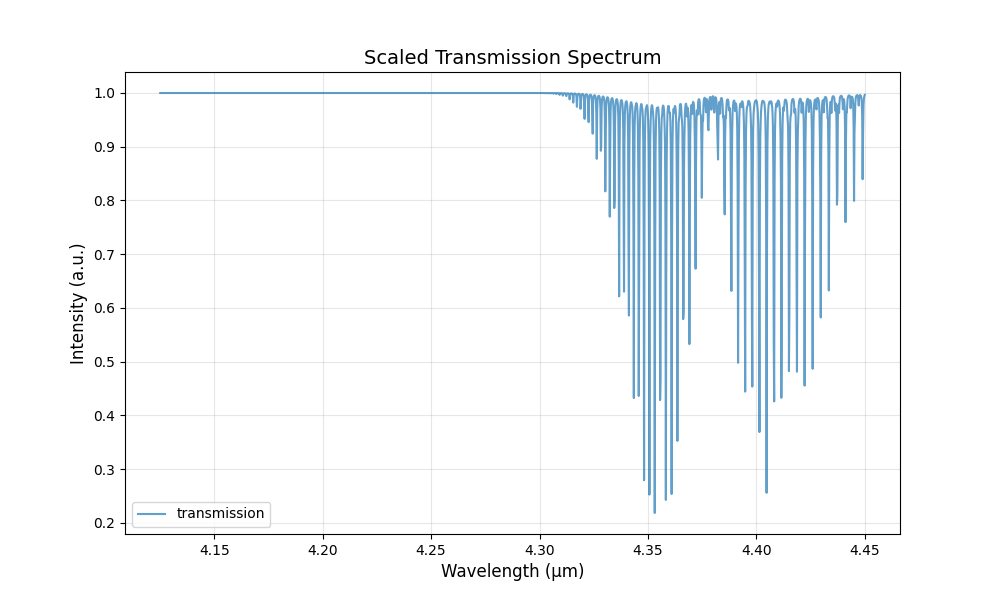

In [12]:
plt.figure(figsize=(10, 6))

isotope_to_plot = 2
dwn_to_plot = 0.1

plt.plot(co2_isotopologue_dictionary[dwn_to_plot][isotope_to_plot]['wavelength_grid'], co2_isotopologue_dictionary[dwn_to_plot][isotope_to_plot]['transmission_scaled'], label='transmission', alpha=0.7)
plt.xlabel('Wavelength (µm)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title('Scaled Transmission Spectrum', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

## Injecting Noise

In [13]:
co2_isotopologue_dictionary_noisy = {}
scale = np.sqrt(10**6*(1/39)**2)
snr_list = [5, 10, 25, scale*5, scale * 10, 1000]

# for dwn, iso_dict in co2_isotopologue_dictionary.items():
    
#     co2_isotopologue_dictionary_noisy[dwn] = {}
    
#     for iso_num, iso_data in iso_dict.items():
        
#         co2_isotopologue_dictionary_noisy[dwn][iso_num] = {}
        
#         for snr in snr_list:
#             noisy_transmission, errorbars = inject_gaussian_noise(iso_data['transmission_normalized'], SNR=snr)
#             print(f"Injected Gaussian noise for dwn={dwn}, iso={iso_num}, SNR={snr}, original min={np.min(iso_data['transmission_normalized']):.4f} → noisy min={np.min(noisy_transmission):.4f}")
            
#             co2_isotopologue_dictionary_noisy[dwn][iso_num][snr] = {
#                 'wavelength_grid': iso_data['wavelength_grid'],
#                 'wn_grid': iso_data['wn_grid'],
#                 'transmission': noisy_transmission,
#                 'spec_res': iso_data['spec_res'],
#                 'iso_name': iso_data.get('iso_name', f'Iso {iso_num}'),
#                 'errorbars': errorbars
#             }

for dwn in co2_isotopologue_dictionary:
    co2_isotopologue_dictionary_noisy[dwn] = {}
    for iso_num in co2_isotopologue_dictionary[dwn]:
        co2_isotopologue_dictionary_noisy[dwn][iso_num] = {}
        for snr in snr_list:
            trans_scaled = co2_isotopologue_dictionary[dwn][iso_num]['transmission_scaled']
            
            noisy_trans, errorbars = inject_gaussian_noise(trans_scaled, SNR=snr)
            # print(f'Original minimum {np.min(trans_scaled)}, noise inject minimum: {np.min(noisy_trans)}')
            
            co2_isotopologue_dictionary_noisy[dwn][iso_num][snr] = {
                'wavelength_grid': co2_isotopologue_dictionary[dwn][iso_num]['wavelength_grid'],
                'transmission': noisy_trans,
                'errorbars': errorbars,
                'iso_name': co2_isotopologue_dictionary[dwn][iso_num].get('iso_name', f'Iso {iso_num}'),
                'spec_res': co2_isotopologue_dictionary[dwn][iso_num]['spec_res']
            }

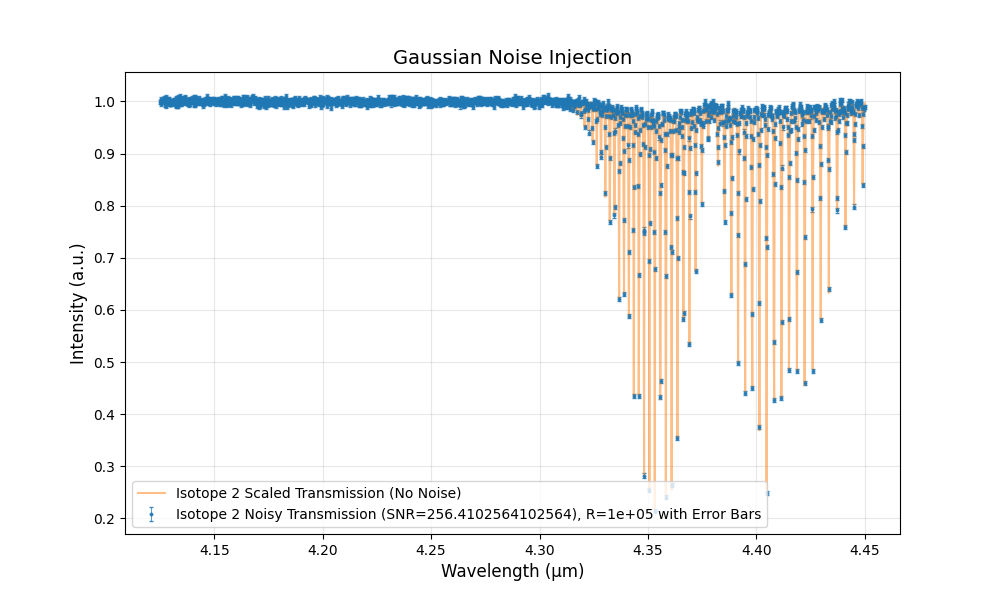

In [14]:
plt.figure(figsize=(10, 6))

snr_to_plot = 10*scale
dwn_to_plot = 0.1
isotope_to_plot = 2
errorbar = True


if errorbar:
        plt.errorbar(co2_isotopologue_dictionary_noisy[dwn_to_plot][isotope_to_plot][snr_to_plot]['wavelength_grid'], co2_isotopologue_dictionary_noisy[dwn_to_plot][isotope_to_plot][snr_to_plot]['transmission'], yerr=co2_isotopologue_dictionary_noisy[dwn_to_plot][isotope_to_plot][snr_to_plot]['errorbars'],
                 fmt='o',                  
                 markersize=1.8,          
                 color='#1f77b4',          
                 ecolor='#1f77b4',        
                 elinewidth=0.6,           
                 capsize=1.2,              
                 alpha=0.85,
                 label=f'Isotope {isotope_to_plot} Noisy Transmission (SNR={snr_to_plot}), R={1e4/dwn_to_plot:.0e} with Error Bars')
        plt.plot(co2_isotopologue_dictionary[dwn_to_plot][isotope_to_plot]['wavelength_grid'], co2_isotopologue_dictionary[dwn_to_plot][isotope_to_plot]['transmission_scaled'], label=f'Isotope {isotope_to_plot} Scaled Transmission (No Noise)', alpha=0.5, color = '#ff7f0e')
else:    
    plt.plot(co2_isotopologue_dictionary_noisy[dwn_to_plot][isotope_to_plot][snr_to_plot]['wavelength_grid'], co2_isotopologue_dictionary_noisy[dwn_to_plot][isotope_to_plot][snr_to_plot]['transmission'], 
             label=f'Isotope {isotope_to_plot} Noisy Transmission (SNR={snr_to_plot}), R={1e4/dwn_to_plot:.0e}', alpha=0.7)
    


plt.xlabel('Wavelength (µm)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title('Gaussian Noise Injection', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()


## Creating Summed Spectrum

In [15]:
print(co2_isotopologue_dictionary_noisy[1][1][5].keys())

dict_keys(['wavelength_grid', 'transmission', 'errorbars', 'iso_name', 'spec_res'])


In [16]:
abundances = {1: .95, 2: .01}
snr_list   = [5, 10, 25, 5*scale, 10*scale, 1000]

summed_spectra = {}

for dwn in co2_isotopologue_dictionary_noisy:
    summed_spectra[dwn] = {}
    
    print(f"Building mixtures for dwn = {dwn} cm⁻¹ ...")
    
    for snr in snr_list:
        wl_grid, summed_transmission = create_abundance_weighted_sum(
            co2_isotopologue_dictionary_noisy, 
            dwn, 
            snr,                 
            abundances
        )
        
        summed_tau = -np.log(summed_transmission)
        
        # noisy_transmission, _ = inject_gaussian_noise(summed_transmission, SNR=snr)
        # noisy_transmission, _ = inject_poisson_noise(summed_transmission, SNR=snr)  # uncomment if you prefer
        
        summed_spectra[dwn][snr] = {
            'summed_transmission_noisy': summed_transmission,
            'wavelength_grid': wl_grid,
            'summed_tau': summed_tau,
        }

Building mixtures for dwn = 0.01 cm⁻¹ ...
Building mixtures for dwn = 0.025 cm⁻¹ ...
Building mixtures for dwn = 0.05 cm⁻¹ ...
Building mixtures for dwn = 0.1 cm⁻¹ ...
Building mixtures for dwn = 0.25 cm⁻¹ ...
Building mixtures for dwn = 0.5 cm⁻¹ ...
Building mixtures for dwn = 1.0 cm⁻¹ ...
Building mixtures for dwn = 10.0 cm⁻¹ ...
Building mixtures for dwn = 5.0 cm⁻¹ ...
Building mixtures for dwn = 6.0 cm⁻¹ ...
Building mixtures for dwn = 8.0 cm⁻¹ ...


In [17]:
print(summed_spectra[0.1][10].keys())

dict_keys(['summed_transmission_noisy', 'wavelength_grid', 'summed_tau'])


In [18]:
# plt.figure(figsize=(10, 6))

# snr_to_plot = 1000
# dwn_to_plot = 0.01
# errorbar = False

# if errorbar:
#         plt.errorbar(summed_spectra[dwn_to_plot][snr_to_plot]['wavelength_grid'], summed_spectra[dwn_to_plot][snr_to_plot]['summed_transmission'], yerr=co2_isotopologue_dictionary_noisy[dwn_to_plot][1][snr_to_plot]['errorbars'],
#                  fmt='o',                  
#                  markersize=1.8,          
#                  color='#1f77b4',          
#                  ecolor='#1f77b4',        
#                  elinewidth=0.6,           
#                  capsize=1.2,              
#                  alpha=0.85,
#                  label=f'Isotope {isotope_to_plot} Noisy Transmission (SNR={snr_to_plot}), R={1e4/dwn_to_plot:.0e} with Error Bars')
#         # plt.plot(summed_spectra[dwn_to_plot][snr_to_plot]['wavelength_grid'], summed_spectra[dwn_to_plot][snr_to_plot]['summed_transmission'], label=f'Isotope {isotope_to_plot} Scaled Transmission (No Noise)', alpha=0.5, color = '#ff7f0e')
#         # plt.plot(co2_isotopologue_dictionary)
# else:    
#     plt.plot(summed_spectra[dwn_to_plot][snr_to_plot]['wavelength_grid'], summed_spectra[dwn_to_plot][snr_to_plot]['summed_transmission_noisy'], 
#              label=f'Summed Spectra Noisy Transmission (SNR={snr_to_plot}), R={1e4/dwn_to_plot:.0e}', alpha=0.7)
    


# plt.xlabel('Wavelength (µm)', fontsize=12)
# plt.ylabel('Intensity (a.u.)', fontsize=12)
# plt.title('Noisy Box Model', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend()


## Cross Correlation Test

### Model test spectra

In [19]:
print(summed_spectra[0.1][10].keys())

dict_keys(['summed_transmission_noisy', 'wavelength_grid', 'summed_tau'])


In [20]:
model_results = []

for dwn in summed_spectra:
    for snr in summed_spectra[dwn]:

        # print(f"Processing dwn={dwn} cm⁻¹, SNR={snr}")

        parent_spectra = summed_spectra[dwn][snr]['summed_transmission_noisy']
        wl = summed_spectra[dwn][snr]['wavelength_grid']
        
        test_data = summed_spectra[dwn][snr]
        test_spectra = test_data['summed_transmission_noisy']
        
        parent_norm = (parent_spectra - np.mean(parent_spectra)) / np.std(parent_spectra) # Zero Mean Cross Correlation
        test_norm   = (test_spectra   - np.mean(test_spectra))   / np.std(test_spectra)
        
        correlation = correlate(parent_norm, test_norm, mode='same')
        correlation /= np.sqrt(np.sum(parent_norm**2) * np.sum(test_norm**2))  # Normalize to max correlation of 1
        
        max_corr = np.max(correlation[len(correlation)//2])

        # SNR and resolution results
        cc_snr = max_corr / np.std(correlation) if np.std(correlation) > 0 else 0
        cc_uncertainty = np.std(correlation)
        resolution = 1e4 / dwn

        model_results.append({
            'dwn': dwn,
            'snr': snr,
            'max_correlation': max_corr,
            'resolution': resolution,
            'cc_snr': cc_snr,
            'cc_uncertainty': cc_uncertainty
        })
            

### 12CO2 Test

In [21]:
co2_12_results = []

for dwn in summed_spectra:
    for snr in summed_spectra[dwn]:

        # print(f"Processing dwn={dwn} cm⁻¹, SNR={snr}")

        parent_spectra = summed_spectra[dwn][snr]['summed_transmission_noisy']
        wl = summed_spectra[dwn][snr]['wavelength_grid']
        
        test_data = co2_isotopologue_dictionary[dwn][1]
        test_spectra = test_data['transmission_scaled']
        
        parent_norm = (parent_spectra - np.mean(parent_spectra)) / np.std(parent_spectra) # Zero Mean Cross Correlation
        test_norm   = (test_spectra   - np.mean(test_spectra))   / np.std(test_spectra)
        
        correlation = correlate(parent_norm, test_norm, mode='same')
        correlation /= np.sqrt(np.sum(parent_norm**2) * np.sum(test_norm**2))  # Normalize to max correlation of 1

        max_corr = np.max(correlation[len(correlation)//2])

        # SNR and resolution results
        cc_snr = max_corr / np.std(correlation)
        cc_uncertainty = np.std(correlation)
        resolution = 1e4 / dwn

        co2_12_results.append({
            'dwn': dwn,
            'snr': snr,
            'max_correlation': max_corr,
            'resolution': resolution,
            'cc_snr': cc_snr,
            'cc_uncertainty': cc_uncertainty
        })


### 13Co2

In [22]:
co2_13_results = []
wavelength_region = (4.3125, 4.45)  # µm

for dwn in summed_spectra:
    for snr in summed_spectra[dwn]:

        # print(f"Processing dwn={dwn} cm⁻¹, SNR={snr}")

        parent_spectra = summed_spectra[dwn][snr]['summed_transmission_noisy']
        parent_spectra = parent_spectra[(summed_spectra[dwn][snr]['wavelength_grid'] >= wavelength_region[0]) &
                                      (summed_spectra[dwn][snr]['wavelength_grid'] <= wavelength_region[1])]
        wl = summed_spectra[dwn][snr]['wavelength_grid']

        test_data = co2_isotopologue_dictionary[dwn][2]
        test_spectra = test_data['transmission']
        test_spectra = test_spectra[(test_data['wavelength_grid'] >= wavelength_region[0]) &
                                    (test_data['wavelength_grid'] <= wavelength_region[1])]

        parent_norm = (parent_spectra - np.mean(parent_spectra)) / np.std(parent_spectra) # Zero Mean Cross Correlation
        test_norm   = (test_spectra   - np.mean(test_spectra))   / np.std(test_spectra)

        correlation = correlate(parent_norm, test_norm, mode='same')
        correlation /= np.sqrt(np.sum(parent_norm**2) * np.sum(test_norm**2))  # Normalize to max correlation of 1

        # max_shift = 0.01 #microns
        # max_shift_pixels = np.abs(int(max_shift // (np.median(np.diff(wl)))))
        # masked_correlation = correlation[len(correlation)//2 - max_shift_pixels : len(correlation)//2 + max_shift_pixels]  

        max_corr = np.max(correlation[len(correlation)//2])  # Focus on central peak for max correlation

        # SNR and resolution results
        cc_snr = max_corr / np.std(correlation)
        cc_uncertainty = np.std(correlation)
        resolution = 1e4 / dwn

        co2_13_results.append({
            'dwn': dwn,
            'snr': snr,
            'max_correlation': max_corr,
            'resolution': resolution,
            'cc_snr': cc_snr,
            'cc_uncertainty': cc_uncertainty
        })


## Cross Correlation Plots

### Model Cross Correlation

In [23]:
# df= pd.DataFrame(model_results)
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# dwn_to_plot = 0.1
# snr_to_plot = 1

# # values = df[df['snr'] == snr_to_plot].sort_values('resolution')
# for snr in df['snr'].unique():
#     values = df[df['snr'] == snr].sort_values('resolution')
#     axes[0].semilogx(values['resolution'], values['cc_snr'], marker='o', label=f'CC SNR (SNR={snr})')
# # axes[0].set_xlabel('Spectral Resolution (R)', fontsize=12)
# axes[0].set_ylabel('Cross-Correlation SNR', fontsize=12)
# axes[0].set_title('Model Template CC SNR vs Spectral Resolution', fontsize=14)
# axes[0].grid(True, alpha=0.3)
# axes[0].legend()

# for snr in df['snr'].unique():
#     values = df[df['snr']==snr].sort_values('resolution')
#     axes[1].semilogx(values['resolution'], values['max_correlation'], marker='o', label=f'Max Correlation (SNR={snr})')
# axes[1].set_xlabel('Spectral Resolution (R)', fontsize=12)
# axes[1].set_ylabel('Max Cross-Correlation', fontsize=12)
# axes[1].set_title('Model Template Max Correlation vs Spectral Resolution', fontsize=14)
# axes[1].grid(True, alpha=0.3)
# axes[1].legend()

### 12CO2 Plot

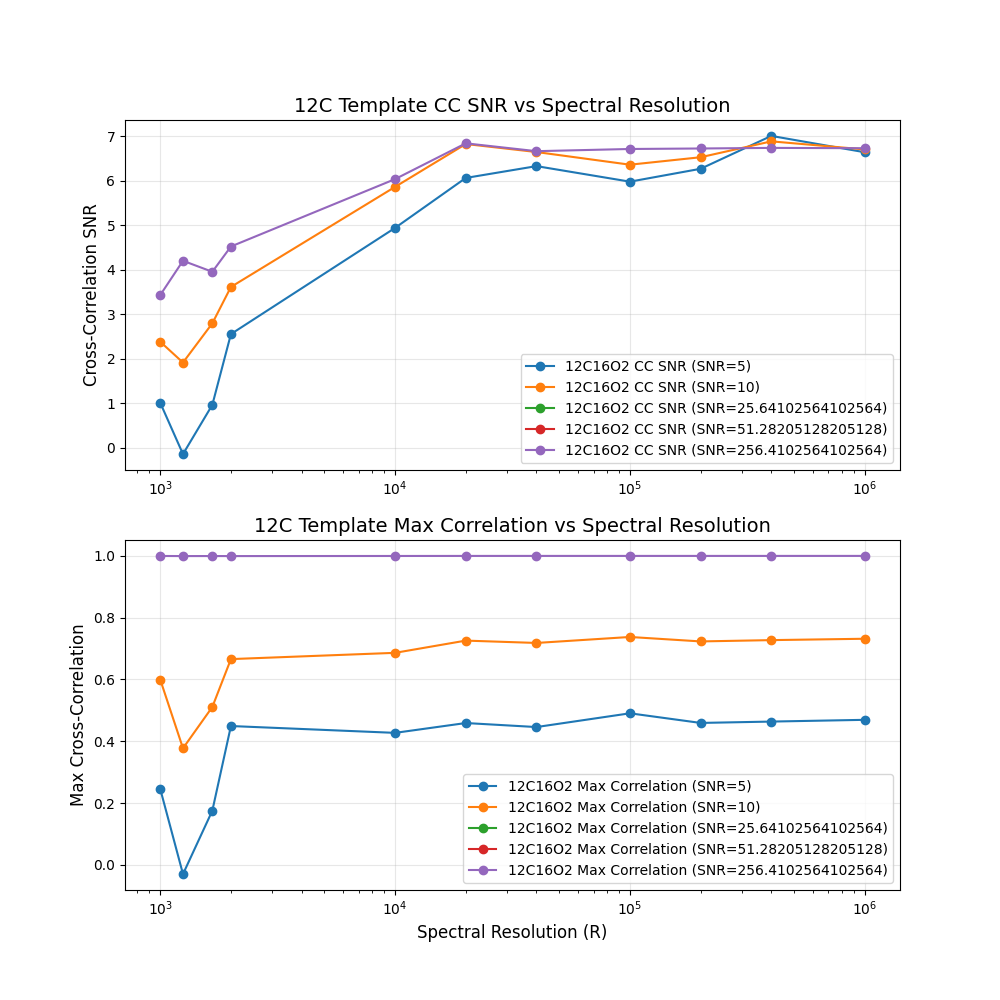

In [30]:
df = pd.DataFrame(co2_12_results)
snr_to_plot = [ 5,10, scale*1, scale*2, scale*10]
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
for snr in snr_to_plot:
    values = df[df['snr'] == snr].sort_values('resolution')
    axes[0].semilogx(values['resolution'], values['cc_snr'], marker='o', label=f'12C16O2 CC SNR (SNR={snr})')

axes[0].text(4000, 20.0, f'12C Weight = {abundances[1]:.2f}\n13C weight = {abundances[2]:.2f}', fontsize=12, color='blue')
# axes[0].set_xlabel('Spectral Resolution (R)', fontsize=12)
axes[0].set_ylabel('Cross-Correlation SNR', fontsize=12)
axes[0].set_title('12C Template CC SNR vs Spectral Resolution', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for snr in snr_to_plot:
    values = df[df['snr']==snr].sort_values('resolution')
    axes[1].semilogx(values['resolution'], values['max_correlation'], marker='o', label=f'12C16O2 Max Correlation (SNR={snr})')
axes[1].set_xlabel('Spectral Resolution (R)', fontsize=12)
axes[1].set_ylabel('Max Cross-Correlation', fontsize=12)
axes[1].set_title('12C Template Max Correlation vs Spectral Resolution', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

## 13C

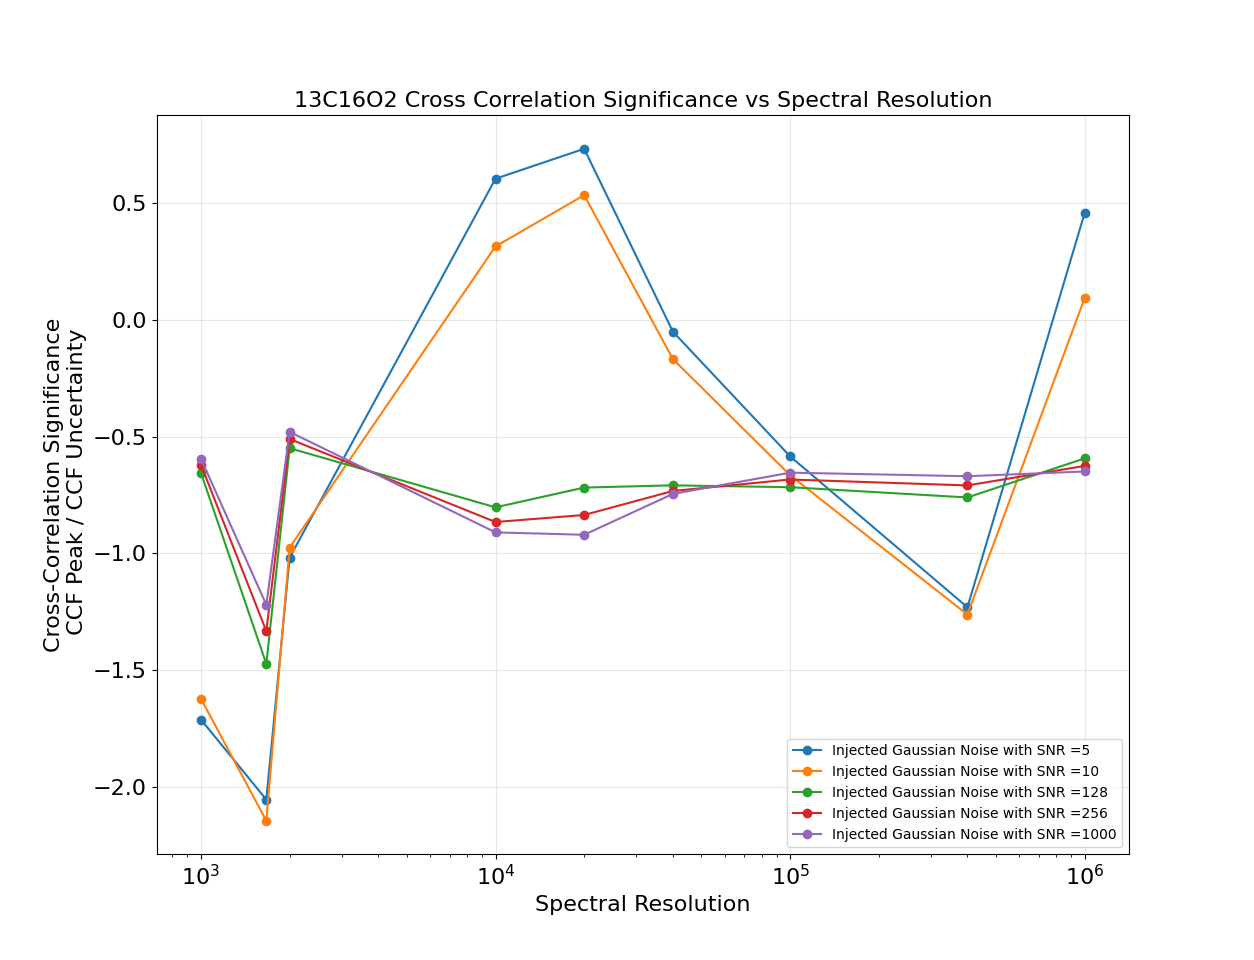

In [26]:
plt.figure(figsize=(12.5424,9.6))

snr_to_plot = [5, 10, scale * 5, scale * 10, 1000]
df = pd.DataFrame(co2_13_results)

corrupted_dwn = [8, 0.05]

for snr in snr_to_plot:
    values = df[
        (df['snr'] == snr) & 
        (~df['dwn'].isin(corrupted_dwn))
    ].sort_values('resolution')
    
    plt.semilogx(values['resolution'], values['cc_snr'], 
                 marker='o', label=f'Injected Gaussian Noise with SNR ={snr:.0f}')

# Abundance annotation
plt.text(4000, 20.0, 
         f'12C Weight = {abundances[1]:.2f}\n13C weight = {abundances[2]:.2f}', 
         fontsize=12, color='blue')

plt.ylabel('Cross-Correlation Significance\n CCF Peak / CCF Uncertainty', fontsize=16)
plt.title('13C16O2 Cross Correlation Significance vs Spectral Resolution', fontsize=16)

plt.xlabel('Spectral Resolution', fontsize=16)           # (you were missing this)
plt.tick_params(axis='x', which='major', labelsize=16)   # makes x-ticks bigger
plt.tick_params(axis='y', which='major', labelsize=16)   # makes y-ticks bigger

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Misc Plots

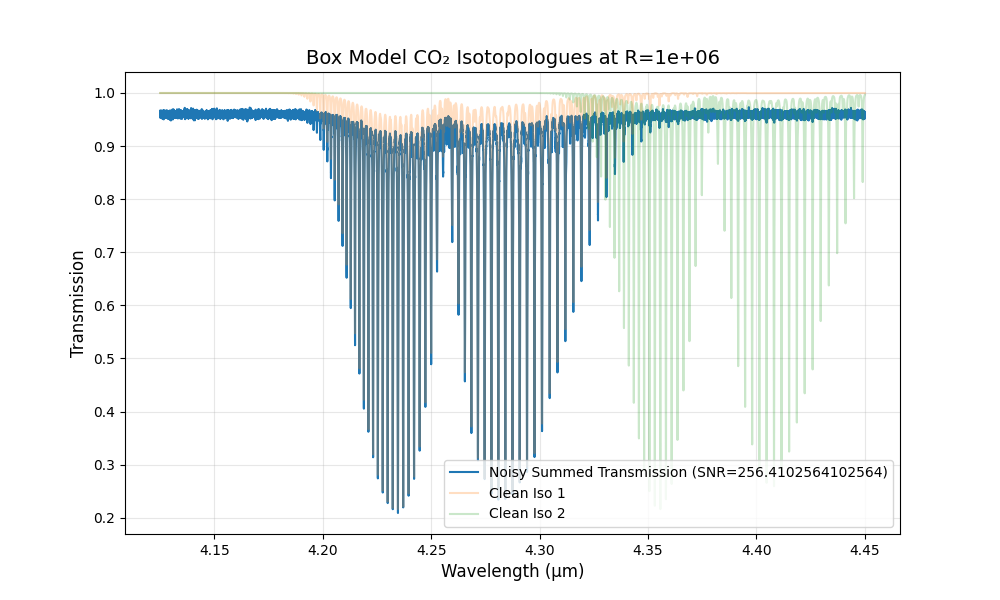

In [28]:
dwn_to_plot = 0.01
snr_to_plot = 10*scale

plt.figure(figsize=(10, 6))
plt.plot(summed_spectra[dwn_to_plot][snr_to_plot]['wavelength_grid'], summed_spectra[dwn_to_plot][snr_to_plot]['summed_transmission_noisy'], label=f'Noisy Summed Transmission (SNR={snr_to_plot})', alpha=1)
plt.plot(co2_isotopologue_dictionary_noisy[dwn_to_plot][1][snr_to_plot]['wavelength_grid'], co2_isotopologue_dictionary[dwn_to_plot][1]['transmission_scaled'], label=f'Clean Iso 1 ', alpha=0.25)
plt.plot(co2_isotopologue_dictionary_noisy[dwn_to_plot][2][snr_to_plot]['wavelength_grid'], co2_isotopologue_dictionary[dwn_to_plot][2]['transmission_scaled'], label=f'Clean Iso 2 ', alpha=0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('Wavelength (µm)', fontsize=12)
plt.ylabel('Transmission', fontsize=12)
plt.title(f'Box Model CO₂ Isotopologues at R={1e4/dwn_to_plot:.0e}', fontsize=14)
plt.legend()

## ELT vs SGL

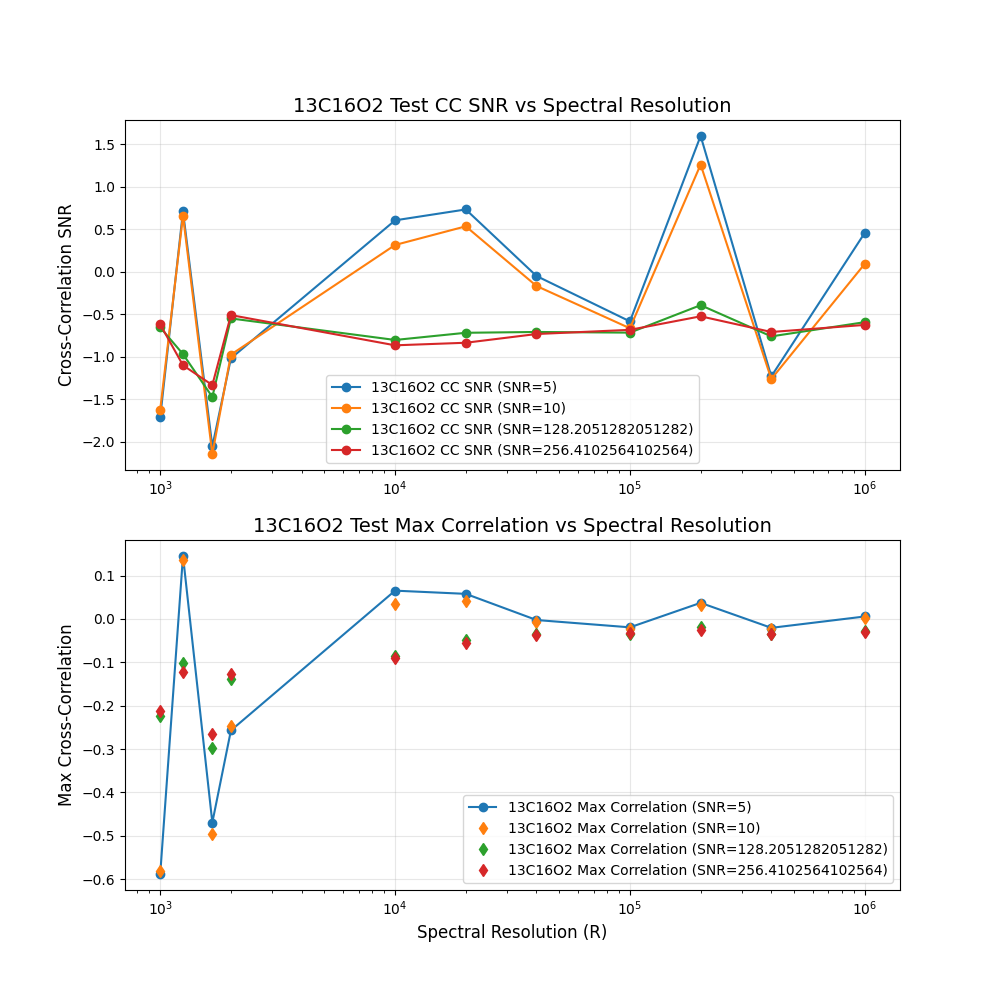

In [29]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
corrupted_dwn = [5,8]
snr_to_plot = [5, 10, scale*5, scale*10]
df = pd.DataFrame(co2_13_results)

for snr in snr_to_plot:
    values = df[df['snr'] == snr].sort_values('resolution')
    if snr >= 10:
        axes[1].semilogx(values['resolution'], values['max_correlation'],'d', markersize=6, label=f'13C16O2 Max Correlation (SNR={snr})')
    else:
        axes[1].semilogx(values['resolution'], values['max_correlation'], marker='o', label=f'13C16O2 Max Correlation (SNR={snr})')

axes[1].set_xlabel('Spectral Resolution (R)', fontsize=12)
axes[1].set_ylabel('Max Cross-Correlation', fontsize=12)
axes[1].set_title('13C16O2 Test Max Correlation vs Spectral Resolution', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for snr in snr_to_plot:
    values = df[df['snr'] == snr].sort_values('resolution')
    if snr >= 10:
        axes[0].semilogx(values['resolution'], values['cc_snr'], marker = 'o',  label=f'13C16O2 CC SNR (SNR={snr})')
    else:
        axes[0].semilogx(values['resolution'], values['cc_snr'], marker='o', label=f'13C16O2 CC SNR (SNR={snr})')
axes[0].set_ylabel('Cross-Correlation SNR', fontsize=12)
axes[0].set_title('13C16O2 Test CC SNR vs Spectral Resolution', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()